# **랭체인 Multi-modal RAG 구현 [옵션 3]**


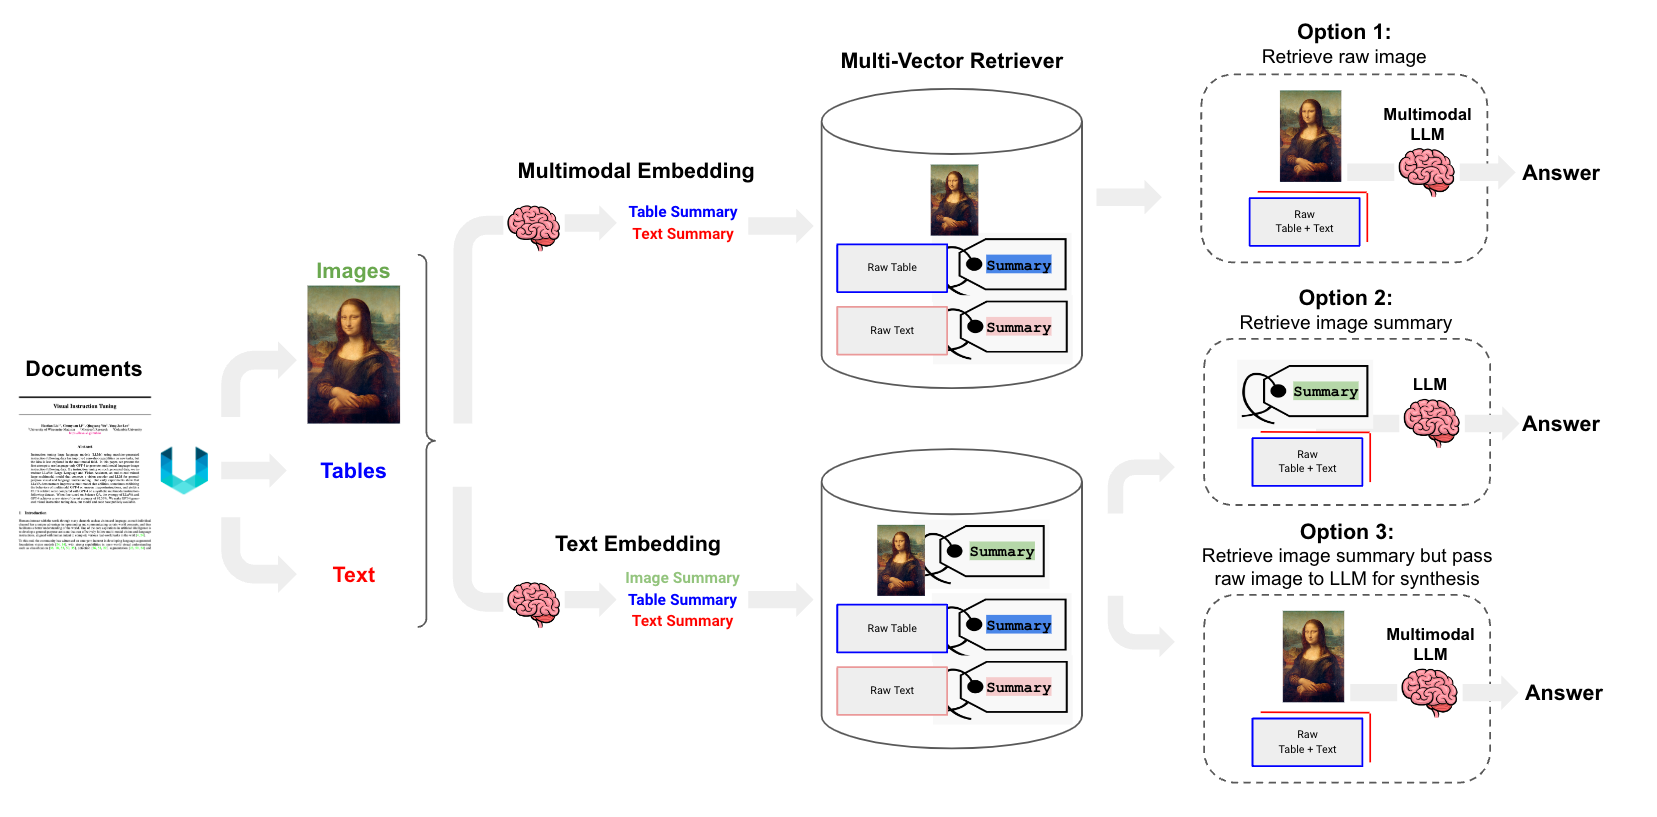

- 이미지 출처: https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb

**3가지 옵션 비교:**

| 옵션 | 임베딩 방식 | 벡터 DB 저장 | 답변 생성 LLM | 이미지 활용 | 장점 | 단점 |
|---|---|---|---|---|---|---|
| 1 | 멀티모달 (CLIP) | 이미지 임베딩, 텍스트 임베딩 | Multimodal | 직접 활용 (base64) | 최고 이미지 활용도, 높은 답변 품질 | 높은 비용, base64 오버헤드 |
| 2 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약) | Text-only | 텍스트 요약 간접 활용 | 비용 효율성, 텍스트 RAG 인프라 활용 | 이미지 정보 손실, 답변 품질 제한적 |
| 3 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약 + 참조) | Multimodal | 원본 이미지 참조 활용 | 옵션 1과 2의 절충, 이미지 정보 손실 감소, 유연성 | 옵션 1보다 이미지 활용도 낮음, 이미지 참조 관리 필요 |

**선택 가이드:**

* **최고 품질 답변:** 옵션 1 (비용 고려)
* **비용 효율성 우선:** 옵션 2 (답변 품질 제한 감수)
* **품질과 효율성 균형:** 옵션 3

---

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

`(3) langfuse handler 설정`

In [ ]:
# from langfuse.langchain import CallbackHandler

# # 콜백 핸들러 생성
# langfuse_handler = CallbackHandler()

`(4) 유틸리티 함수`

In [3]:
import base64
import io
from io import BytesIO

import numpy as np
from PIL import Image
from IPython.display import HTML, display
from langchain_core.documents import Document

import pickle
from langchain_core.stores import InMemoryStore


def is_base64(s):
    """문자열이 Base64로 인코딩되었는지 확인합니다"""
    try:
        return base64.b64encode(base64.b64decode(s)) == s.encode()
    except Exception:
        return False


def split_image_text_types(docs):
    """numpy 배열 이미지와 텍스트를 분리합니다"""
    images = []
    text = []
    for doc in docs:
        if isinstance(doc, str):
            pass
        elif isinstance(doc, Document):
            doc = doc.page_content  # 문서 내용 추출
        else:
            doc = doc.text # 문서 내용 추출

        if is_base64(doc):
            images.append(doc)  # base64로 인코딩된 문자열
        else:
            text.append(doc)
    return {"images": images, "texts": text}


def plt_img_base64(img_base64):
    """
    Base64로 인코딩된 이미지를 주피터 노트북에 표시
    
    매개변수:
    img_base64 (str): Base64로 인코딩된 이미지 문자열
    """
    # Base64 문자열을 소스로 하는 HTML img 태그 생성
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'

    # HTML을 렌더링하여 이미지 표시
    display(HTML(image_html))

---

## **증권사 분석보고서 문서 로드**

- PDF 문서에서 이미지, 텍스트, 테이블 분리


### 1. **데이터 로딩 및 파싱** 

- 메모리 부족할 경우 별도의 실습파일을 활용 

In [4]:
# 데이터 저장 폴더 경로
data_path = "data/analyst_reports/" 

# PDF 파일이 있는  경로
pdf_files = glob(os.path.join(data_path, "*.pdf"))  

# 이미지를 저장할 경로
image_output_dir = os.path.join(data_path, 'images')  

os.makedirs(image_output_dir, exist_ok=True)

print(f"PDF files:")
pprint(pdf_files)

PDF files:
['data/analyst_reports/20240531_company_652771000.pdf',
 'data/analyst_reports/20240524_company_234017000.pdf',
 'data/analyst_reports/20240531_company_753270000.pdf']


In [5]:
# 청크 로드
import pickle

with open(os.path.join(data_path, "pdf_base64_chunks.pkl"), "rb") as f: 
    pdf_chunks = pickle.load(f)

# 청크 개수 확인
print(len(pdf_chunks))

34


---

## **[옵션 3]** 멀티모달 LLM으로 이미지 + 요약 활용해서 생성 

- **멀티모달 LLM** 모델(GPT4-V, LLaVA 등)을 사용하여 이미지에서 **텍스트 요약**을 생성
- 생성된 텍스트를 **임베딩**하고 필요할 때 **검색**
- 검색 시 텍스트 청크와 함께 **원본 이미지**를 가져옴
- 최종 답변 생성 단계에서 **멀티모달 LLM**에 텍스트와 원본 이미지를 함께 전달

`(1) 타입별 구분`

In [6]:
# 타입별 분류
tables = []
texts = []
images = []
image_metas = []  # 이미지와 평행한 page_number / filename 메타


def _resolve_filename(meta):
    """meta.filename → orig_elements 폴백. 추측은 하지 않음 (단일 PDF 가정 X)."""
    fn = getattr(meta, "filename", None)
    if fn:
        return fn
    orig = getattr(meta, "orig_elements", None)
    if orig:
        for el in orig:
            inner = getattr(el.metadata, "filename", None)
            if inner:
                return inner
    return None


for chunk in pdf_chunks:
    # 테이블 청크
    if "Table" in str(type(chunk)):
        tables.append(chunk)
    # 텍스트 청크 (CompositeElement)
    elif "CompositeElement" in str(type(chunk)):
        texts.append(chunk)

# 이미지 추출 + page_number / filename 평행 추적
for chunk in pdf_chunks:
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for el in chunk.metadata.orig_elements:
            if hasattr(el.metadata, 'image_base64') and el.metadata.image_base64:
                images.append(el.metadata.image_base64)
                image_metas.append({
                    "page_number": getattr(el.metadata, "page_number", None),
                    "filename": _resolve_filename(el.metadata),
                })

print(f"📊 테이블 청크: {len(tables)}개")
print(f"📝 텍스트 청크: {len(texts)}개")
print(f"🖼️ 이미지: {len(images)}개")

# 진단: filename 미해결 청크 — 0 이 아니면 cell 14 재실행 권장
_none_text = sum(1 for t in texts if _resolve_filename(t.metadata) is None)
_none_table = sum(1 for t in tables if _resolve_filename(t.metadata) is None)
_none_image = sum(1 for m in image_metas if m["filename"] is None)
if _none_text or _none_table or _none_image:
    print(
        f"⚠️ filename 미해결: texts={_none_text}, tables={_none_table}, images={_none_image}"
        "\n    → cell 14 (force-set filename) 를 재실행해야 출처가 정확히 기록됩니다."
    )
else:
    print("✅ 모든 chunk 의 filename 해결됨")


📊 테이블 청크: 8개
📝 텍스트 청크: 26개
🖼️ 이미지: 33개
✅ 모든 chunk 의 filename 해결됨


In [7]:
# 테이블 청크 확인
tables[0]

In [8]:
# 텍스트 청크 확인
texts[0]


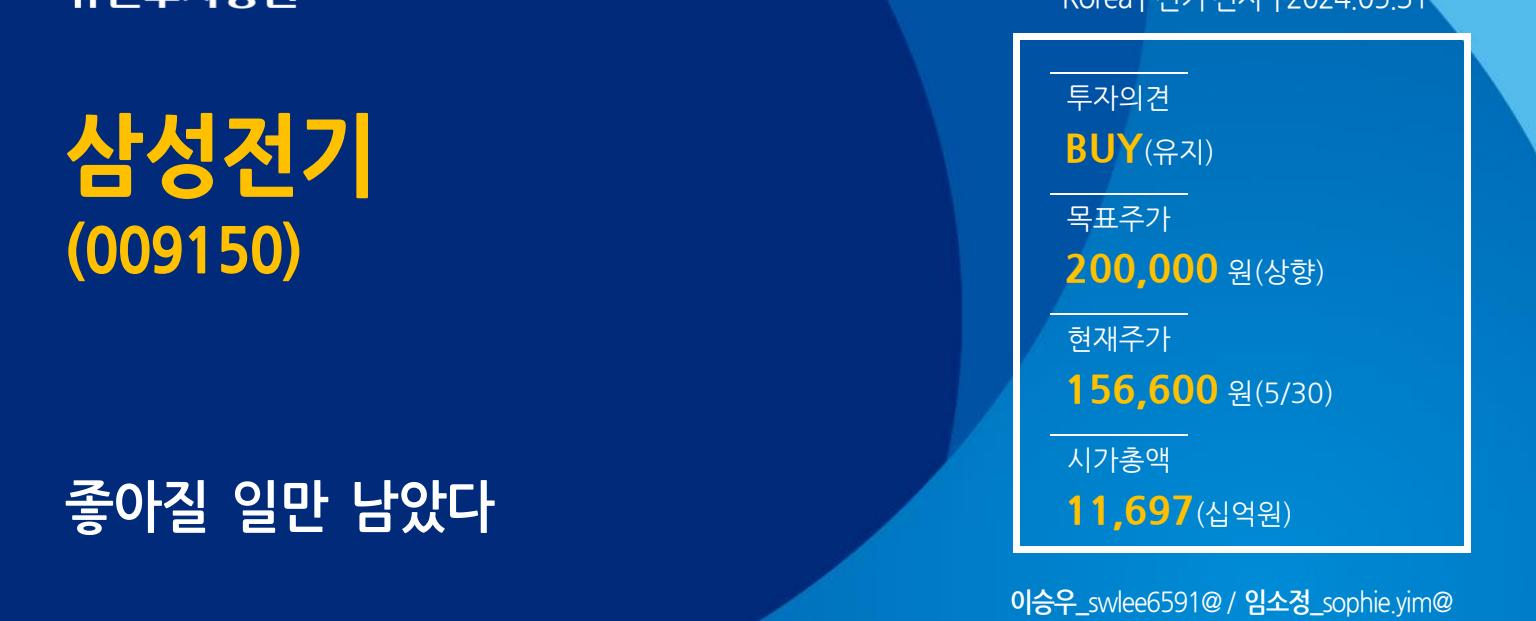

In [9]:
# 이미지 청크 확인
plt_img_base64(images[0])

`(2) 이미지, 표 요약`

In [10]:
# Part2에서 요약한 결과를 로드
output_dir = "data/analyst_reports/summaries"
os.makedirs(output_dir, exist_ok=True)

# 요약된 텍스트 로드
with open(os.path.join(output_dir, "summaries.json"), "r", encoding="utf-8") as f:
    summary_data = json.load(f)

text_summaries = summary_data.get("text_summaries", [])
table_summaries = summary_data.get("table_summaries", [])
image_summaries = summary_data.get("image_summaries", [])

print(f"📄 텍스트 요약: {len(text_summaries)}개")
print(f"📊 표 요약: {len(table_summaries)}개")
print(f"🖼️ 이미지 요약: {len(image_summaries)}개"   )

📄 텍스트 요약: 26개
📊 표 요약: 8개
🖼️ 이미지 요약: 33개


`(3) 벡터스토어에 저장`

In [11]:
from langchain_core.stores import InMemoryStore
import pickle

def save_store_to_disk(store: InMemoryStore, path: str):
    """InMemoryStore를 디스크에 저장"""
    data = dict(store.store)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"💾 Store 저장: {path}")


def load_store_from_disk(path: str):
    """디스크에서 InMemoryStore 로드"""
    with open(path, 'rb') as f:
        data = pickle.load(f)
    new_store = InMemoryStore()
    new_store.store = data
    return new_store

In [12]:
import uuid

from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_core.stores import InMemoryStore
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings

# 자식 청크를 인덱싱하기 위한 벡터 저장소 (mm_* prefix 로 상류 namespace 충돌 방지)
mm_vectorstore = Chroma(
    collection_name="mm_summaries_base64",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db",  # Part1/2 와 동일 디렉터리 (컬렉션명으로 분리)
)

# 부모 문서를 위한 저장 레이어
mm_store = InMemoryStore()
id_key = "doc_id"

# 검색기 생성
mm_retriever = MultiVectorRetriever(
    vectorstore=mm_vectorstore,
    docstore=mm_store,
    id_key=id_key,
)


In [ ]:
# retriever.vectorstore.delete_collection()  # 기존 컬렉션 삭제

In [13]:
### 텍스트 추가 ###

# 각 텍스트에 대한 고유 ID 생성
doc_ids = [str(uuid.uuid4()) for _ in texts]


def _meta(doc_id, src, page=None, doc_name=None):
    return {id_key: doc_id, "source": src, "page_number": page, "doc_name": doc_name}


# 텍스트 요약 문서 (★ page_number / doc_name 메타 부착 — 인용 가능)
summary_texts = [
    Document(page_content=s, metadata=_meta(
        doc_ids[i], "text",
        page=getattr(texts[i].metadata, "page_number", None),
        doc_name=_resolve_filename(texts[i].metadata),
    ))
    for i, s in enumerate(text_summaries)
]

# 원본 텍스트 문서
original_texts = [
    Document(page_content=t.text, metadata=_meta(
        doc_ids[i], "text",
        page=getattr(t.metadata, "page_number", None),
        doc_name=_resolve_filename(t.metadata),
    ))
    for i, t in enumerate(texts)
]

# 벡터 저장소에 텍스트 요약 추가
mm_retriever.vectorstore.add_documents(summary_texts)

# 문서 저장소에 원본 텍스트 추가
mm_retriever.docstore.mset(list(zip(doc_ids, original_texts)))

print(f"📄 텍스트 요약 추가: {len(summary_texts)}개")


📄 텍스트 요약 추가: 26개


In [14]:
# 검색 테스트
query = "2023년 2분기 매출은 얼마인가요?"
docs = mm_retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 4개
ID: e1143cc4-e217-48ba-9786-c93169252dd0
Source: text
Content: 00,000 156,600 11,697

ㆍ 1 분 기 HAS 매출 22 6,243 억 원, 영 업 이익 1,803 억 원 으로 각각 전년비 30%, 29% 증가. (8 컴 포 넌 트 사 업 부 는 부진한 세트 수 요 에도 불 구 하고 시 관련 산업용 제 품 과 전 장 용 제품 매출 비중 증 가 에 따른 제품 믹스 개 선 으로 출 하 량 감 소 에도 전 기...
ID: 2ad2ea6f-d5ab-453c-97f7-c9b4cda4df87
Source: text
Content: 주 가

( 원 5/30) 106,300 시 가 총 액 (십억원) 17,396 발 행 주식수 163,648 천 주 22 최고가 132.400 원 최저가 90.300 원 52% 일간 Beta 1.05 60% 일 평 균 거 래 대금 719 억 원 외국인 지분율 311% 배 당 수 익 를 (20248 07% . aan LG (2| 3 인 ) 33.7% 국 민 연...
ID: 4a0ecbe6-db8b-44fb-8913-fb52a977c393
Source: text
Content: 50,000 106,300 17,396

ㆍ {분기 AAS 매출 212 959 억 원, 영 업 이익 12 3,354 억 원 으로 전 사 업 부 의 매 출 이 전년비 증 가 했지만 LCD 패널 가격 상승, 마케팅 비용 증가 등 원가 부담 요 인 으로 인해 수 익 성 은 소폭 하락. 07184 사 업 부는 글로벌 경기 둔화 에도 불구, 보급형 제품 물량 확 대...
ID: 2cfca1b7-1031-4c48-8afd-3960eaae0ba7
Source: text
Content: ㆍ 25 년 예상 BPS 기준 19796[『/8 1.9 배 를 적 용 해 목 표 가 를 20 만 원 으로 상 향 하고 투 자 의견 BUY 유지.

주 가 원 530) 156,600 시 가 총 액 (십억원) 11,697

In [15]:
### 테이블 요약 추가 ###

# 각 테이블에 대한 고유 ID 생성
table_ids = [str(uuid.uuid4()) for _ in table_summaries]

# 테이블 요약 문서 (메타 부착)
summary_tables = [
    Document(page_content=s, metadata=_meta(
        table_ids[i], "table",
        page=getattr(tables[i].metadata, "page_number", None),
        doc_name=_resolve_filename(tables[i].metadata),
    ))
    for i, s in enumerate(table_summaries)
]

# 원본 테이블 문서 — Table element 는 metadata.text_as_html 직접 보유
# (이전 코드의 t.metadata.orig_elements[0]... 패턴은 top-level Table 에서 AttributeError)
original_tables = [
    Document(
        page_content=getattr(t.metadata, "text_as_html", None) or t.text,
        metadata=_meta(
            table_ids[i], "table",
            page=getattr(t.metadata, "page_number", None),
            doc_name=_resolve_filename(t.metadata),
        ),
    )
    for i, t in enumerate(tables)
]

# 벡터 저장소에 테이블 요약 추가
mm_retriever.vectorstore.add_documents(summary_tables)

# 문서 저장소에 원본 테이블 추가
mm_retriever.docstore.mset(list(zip(table_ids, original_tables)))

print(f"📄 테이블 요약 추가: {len(summary_tables)}개")


📄 테이블 요약 추가: 8개


In [16]:
# 검색 테스트
query = "2023년 2분기 매출은 얼마인가요?"
docs = mm_retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 4개
ID: 80cbe0f0-ed5f-44e9-96da-accd3d73594a
Source: table
Content: <table><tr><td>손 익 계산서</td><td/><td/><td/><td/><td/></tr><tr><td>( 단 위 : 십 억원)</td><td>20224</td><td>2023A</td><td>2024F</td><td>2025F</td><td>2026F</td></tr><tr><td>매출액</td><td>2284</td><td>2176</td>...
ID: d45583b8-9b8a-4ed7-a193-3ec94ced4d0e
Source: table
Content: <table><tr><td>손 익 계산서 ( 단 위 : 십 억원)</td><td>2022A</td><td>= 20234</td><td>202 사</td><td>202 다</td><td>2026</td></tr><tr><td>매출액</td><td>9425</td><td>8909</td><td>10,121</td><td>10,919</td><td>11,787<...
ID: e1143cc4-e217-48ba-9786-c93169252dd0
Source: text
Content: 00,000 156,600 11,697

ㆍ 1 분 기 HAS 매출 22 6,243 억 원, 영 업 이익 1,803 억 원 으로 각각 전년비 30%, 29% 증가. (8 컴 포 넌 트 사 업 부 는 부진한 세트 수 요 에도 불 구 하고 시 관련 산업용 제 품 과 전 장 용 제품 매출 비중 증 가 에 따른 제품 믹스 개 선 으로 출 하 량 감 소 에도 전 기...
ID: 2ad2ea6f-d5ab-453c-97f7-c9b4cda4df87
Source: text
Content: 주 가

( 원 5/30) 106,300 시 가 총 액 (십억원) 17,396 발 행 주식수 163,648 천 주 22 최고가 132.400 원 최저가 90.300 원 52% 일간 Beta 1.05 60% 일 평 

In [17]:
# 인덱싱할 이미지 개수 확인 (전체 출력은 base64 가 길어 생략)
print(f"이미지: {len(images)} 개, 첫 항목 길이 {len(images[0]) if images else 0} chars")


이미지: 33 개, 첫 항목 길이 93520 chars


In [18]:
# 이미지 추가 — ★ Option 3 은 멀티모달 LLM 사용 → docstore 에 base64 원본 유지
img_ids = [str(uuid.uuid4()) for _ in image_summaries]

# 이미지 요약 문서 (vectorstore 검색용)
summary_images = [
    Document(page_content=s, metadata=_meta(
        img_ids[i], "image",
        page=image_metas[i]["page_number"] if i < len(image_metas) else None,
        doc_name=image_metas[i]["filename"] if i < len(image_metas) else None,
    ))
    for i, s in enumerate(image_summaries)
]

# 원본 이미지 문서 (docstore — 답변 시 vision LLM 에 직접 전달)
original_images = [
    Document(page_content=img, metadata=_meta(
        img_ids[i], "image",
        page=image_metas[i]["page_number"] if i < len(image_metas) else None,
        doc_name=image_metas[i]["filename"] if i < len(image_metas) else None,
    ))
    for i, img in enumerate(images)
]

# 벡터 저장소에 이미지 요약 추가 (검색용)
mm_retriever.vectorstore.add_documents(summary_images)

# 문서 저장소에 원본 이미지(base64) 추가 (LLM 입력용)
mm_retriever.docstore.mset(list(zip(img_ids, original_images)))

print(f"📄 이미지 추가: {len(img_ids)}개")


📄 이미지 추가: 33개


In [19]:
# 검색 테스트
query = "삼성전기의 과거 2년간 투자 의견은 무엇인가요?"
docs = mm_retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 4개
ID: a73d38b4-09b9-4874-a489-9a1b20322a9e
Source: image
Content: /9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIy...
ID: 021ed21a-063d-4e59-8868-f7ebd0621f8c
Source: text
Content: 투 자 기간 및 투 자 등 급 / 투 자 의 견

투 자 기간 및 투 자 등 급 / 투 자 의 견 종 목 추천 및 업 종 추천 투 자 기간: 12 개 월 {( 추 천 기 준 일 종 가 대비 추 천 종 목 의 예상 목 표 수 익 률 을 의 미 함 ) 당사 투 자 의견 비 율 (%) - STRONG BUY (OH) 추 천 기준일 종 가 대비 +50% 이 상 1...
ID: ec0e5aa8-9aa8-4c6d-9aef-bff1fbb7b31e
Source: image
Content: /9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIy...
ID: 7504ece4-bcee-4e48-a1c5-0a9a06377f30
Source: text
Content: 삼 성 전 기

삼 성 전 기 (009150.9) 재 무 제표

대 차 대조표

( 단 위 : 십 억원) 20224 20234 20240 202 202 자 산 총계 10.997 11,658 11,969 13,007

In [20]:
# store 저장
save_store_to_disk(mm_store, "mm_summaries_base64.pkl")


💾 Store 저장: mm_summaries_base64.pkl


In [21]:
# store 로드
loaded_store = load_store_from_disk("mm_summaries_base64.pkl")

# 벡터 저장소 로드
mm_vectorstore = Chroma(
    collection_name="mm_summaries_base64",
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db",
)

# 로드한 저장소로 새 검색기 만들기
mm_retriever = MultiVectorRetriever(
    vectorstore=mm_vectorstore,
    docstore=loaded_store,
    id_key=id_key,
)


In [22]:
# 벡터 스토어에서 문서 검색
docs = mm_retriever.invoke("삼성전기에 대한 투자의견과 목표가는?")
print(f"검색된 문서 개수: {len(docs)}")

for doc in docs:
    print(doc.metadata.get("source"), "·", doc.metadata.get("doc_name"), "· page", doc.metadata.get("page_number"))
    if doc.metadata.get("source") != "image":
        print(doc.page_content[:300])
    else:
        print("(image base64 — len:", len(doc.page_content), ")")
    print("=" * 100)


검색된 문서 개수: 4
image · 20240531_company_652771000.pdf · page 1
(image base64 — len: 93520 )
image · 20240531_company_652771000.pdf · page 3
(image base64 — len: 61556 )
text · 20240531_company_652771000.pdf · page 3
투 자 기간 및 투 자 등 급 / 투 자 의 견

투 자 기간 및 투 자 등 급 / 투 자 의 견 종 목 추천 및 업 종 추천 투 자 기간: 12 개 월 {( 추 천 기 준 일 종 가 대비 추 천 종 목 의 예상 목 표 수 익 률 을 의 미 함 ) 당사 투 자 의견 비 율 (%) - STRONG BUY (OH) 추 천 기준일 종 가 대비 +50% 이 상 1% -80 매 수) 추 천 기준일 종 가 대비 +15% 이 상 ~+50% 미 만 93% 1010( 중 립 ) 추 천 기준일 종 가 대비 -10% 이 상 ~ +15% 미 만 5% »
text · 20240531_company_652771000.pdf · page 2
삼 성 전 기

삼 성 전 기 (009150.9) 재 무 제표

대 차 대조표

( 단 위 : 십 억원) 20224 20234 20240 202 202 자 산 총계 10.997 11,658 11,969 13,007 14,240 유 동 자산 4888 5,208 5,050 6208 7,529 현 금 성 자산 1737 17728 2.000 2933 4007 매 출 채권 1,062 1,241 1,088 1,172 1,263 재 고 자산 1,902 2,120 1,841 1,982 2,136 비 유 동 자산 6.109 6449 6919 679



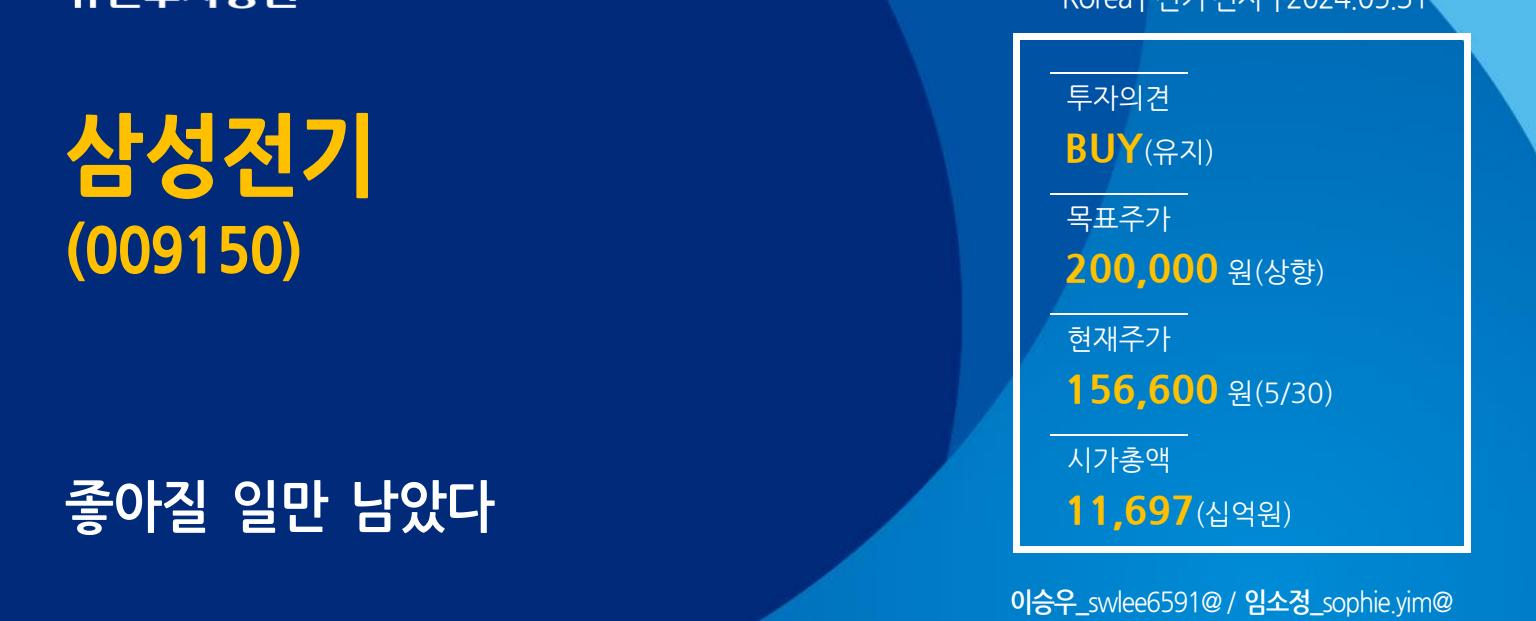

In [23]:
# 검색 결과 중 이미지 doc 첫 번째를 찾아 시각화 (마지막 doc 가정 X)
_img_doc = next((d for d in docs if d.metadata.get("source") == "image"), None)
if _img_doc is not None:
    plt_img_base64(_img_doc.page_content)
else:
    print("⚠️ 검색 결과에 이미지 doc 가 없습니다.")


In [24]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser


def split_docs_by_type_with_meta(docs):
    """검색된 Document 리스트를 source 별로 분리.
    - texts/tables: Document 자체 보존 (page_number / doc_name 메타 인용 가능)
    - images: base64 문자열 (vision LLM 의 image_url part 에 직접 사용)
    """
    out = {"texts": [], "tables": [], "images": []}
    for d in docs:
        src = d.metadata.get("source")
        if src == "image":
            out["images"].append(d.page_content)
        elif src == "table":
            out["tables"].append(d)
        else:
            out["texts"].append(d)
    return out


def process_prompt(kwargs, *, verbose: bool = False):
    """검색 결과 → 멀티모달 HumanMessage (text + image_url parts).

    - 표준 반환: List[BaseMessage] (ChatPromptTemplate 객체 반환 X — fragile)
    - 텍스트/표는 [N] · doc · page 헤더로 분리 — LLM 이 인용 가능
    - 이미지는 별도 image_url part 로 첨부 — vision LLM 이 직접 봄
    """
    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    if verbose:
        print(f"검색: 텍스트 {len(docs_by_type['texts'])}, 표 {len(docs_by_type['tables'])}, 이미지 {len(docs_by_type['images'])}")

    # 텍스트 + 표 컨텍스트 (메타 인용 헤더 포함)
    blocks = []
    idx = 1
    for d in docs_by_type["texts"]:
        page = d.metadata.get("page_number", "?")
        doc_name = d.metadata.get("doc_name") or "Unknown"
        blocks.append(f"[{idx}] (text · {doc_name} · page {page})\n{d.page_content[:1500]}")
        idx += 1
    for d in docs_by_type["tables"]:
        page = d.metadata.get("page_number", "?")
        doc_name = d.metadata.get("doc_name") or "Unknown"
        blocks.append(f"[{idx}] (table · {doc_name} · page {page})\n{d.page_content[:1500]}")
        idx += 1
    context_text = "\n\n".join(blocks) if blocks else "(no text/table context)"

    instruction = (
        "Based solely on the provided context, answer the question from a business analysis perspective.\n"
        "The context includes text/table blocks (with [N] · doc · page citations) and may include attached images.\n"
        "When citing, reference the [N] number and doc·page. Avoid assumptions not supported by the context.\n\n"
        f"[Context]\n{context_text}\n\n"
        f"[Question]\n{user_question}\n\n"
        "[Answer (in 한국어)]"
    )

    parts = [{"type": "text", "text": instruction}]
    for b64 in docs_by_type["images"]:
        parts.append({
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{b64}"},
        })

    return [HumanMessage(content=parts)]


# 기본 RAG 파이프라인 (Option 3 — 멀티모달 LLM)
rag_chain = (
    {
        "context": mm_retriever | RunnableLambda(split_docs_by_type_with_meta),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(process_prompt)
    | ChatOpenAI(model="gpt-4.1-mini")  # vision capable
    | StrOutputParser()
)

# 실행
result = rag_chain.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?")
print(result)


삼성전기의 2024년 실적은 매출액 3,499억 원, 영업이익 569억 원, 순이익 464억 원으로 전망되고 있습니다. 영업이익률은 16%, 순이익률은 13%로 예상되며, 분기별로는 1분기부터 4분기까지 영업이익과 순이익이 점차 개선되어 4분기에는 영업이익률 26%, 순이익률 19%에 달할 것으로 보입니다. 또한, 2024년 연간 영업이익과 순이익이 각각 크게 증가할 것으로 기대되며, 2025년에는 더욱 높은 성장세가 예상됩니다 [문서 1·2, 20240531_company_652771000.pdf]. 

투자 의견도 ‘BUY’가 유지되고 있으며, 목표 주가는 20만 원으로 상향 조정되었습니다. PER은 2024년에 174배, ROE는 86%, PBR은 16배 수준으로 평가되고, 실적 개선과 함께 주가 상승 기대감이 반영되어 있습니다 [문서 2·페이지 1].

요약하면, 삼성전기는 2024년 실적이 견조한 증가세를 보일 것으로 전망되며, 수익성 및 성장성 측면에서 긍정적인 평가를 받고 있습니다.


In [25]:
# 소스를 포함한 확장 RAG 파이프라인
from langchain_core.runnables import RunnableParallel

rag_chain_with_sources = RunnableParallel({
    "context": mm_retriever | RunnableLambda(split_docs_by_type_with_meta),
    "question": RunnablePassthrough(),
}).assign(
    response=(
        RunnableLambda(process_prompt)
        | ChatOpenAI(model="gpt-4.1-mini")  # cell 54 와 통일 (production 에선 gpt-4.1 권장)
        | StrOutputParser()
    )
)


In [26]:
# RAG 파이프라인 실행
result = rag_chain_with_sources.invoke("삼성전기의 2024년 3분기 영업이익률과 순이익률 전망치는?")

# 결과 출력
print(result['response'])

# 검색된 문서
print(result['context'])

삼성전기의 2024년 3분기 영업이익률 전망치는 22%, 순이익률 전망치는 18%입니다[3·page 7].
{'texts': [Document(metadata={'doc_id': '7504ece4-bcee-4e48-a1c5-0a9a06377f30', 'source': 'text', 'page_number': 2, 'doc_name': '20240531_company_652771000.pdf'}, page_content='삼 성 전 기\n\n삼 성 전 기 (009150.9) 재 무 제표\n\n대 차 대조표\n\n( 단 위 : 십 억원) 20224 20234 20240 202 202 자 산 총계 10.997 11,658 11,969 13,007 14,240 유 동 자산 4888 5,208 5,050 6208 7,529 현 금 성 자산 1737 17728 2.000 2933 4007 매 출 채권 1,062 1,241 1,088 1,172 1,263 재 고 자산 1,902 2,120 1,841 1,982 2,136 비 유 동 자산 6.109 6449 6919 6798 6710 투 자 자 산 724 695 705 734 763 유 형 자산 5235 5603 6056 5894 5,767 기 티 150 151 158 171 180 부 채 총계 3304 3628 4,026 4,456 4,940 유 동 부차 2525 2,900 3196 3529 3914 매 입 채무 1.239 1,325 1,119 1,205 1,299 유 동 성 이 자 부채 1,109 1,330 1,829 2,073 2363 기 티 178 245 248 250 253 비 유 동 부채 779 727 830 928 _ 1026 비 유 동 이 자 부채 397 267 305 384 464 기 티 382 460 525 543 562 자 본 총계 7,693 8,030 7,943 8551 9300 지 배 지분 7538 7848 7,753 8361 9110 자본금 388 388 388 388 388 자 본 잉여금 1,054

In [27]:
# 검색된 텍스트 문서들의 메타데이터 + 본문 일부
for d in result["context"]["texts"]:
    print(f"· {d.metadata.get('doc_name', 'Unknown')} | page {d.metadata.get('page_number', '?')}")
    print(f"  {d.page_content[:200]}")


· 20240531_company_652771000.pdf | page 2
  삼 성 전 기

삼 성 전 기 (009150.9) 재 무 제표

대 차 대조표

( 단 위 : 십 억원) 20224 20234 20240 202 202 자 산 총계 10.997 11,658 11,969 13,007 14,240 유 동 자산 4888 5,208 5,050 6208 7,529 현 금 성 자산 1737 17728 2.000 2933 4007 매 
· 20240531_company_652771000.pdf | page 1
  ㆍ 25 년 예상 BPS 기준 19796[『/8 1.9 배 를 적 용 해 목 표 가 를 20 만 원 으로 상 향 하고 투 자 의견 BUY 유지.

주 가 원 530) 156,600 시 가 총 액 (십억원) 11,697 . ： 발 행 주식수 | 74.694 천 주 2 주 최고가 165.000 원 none 119,108 52 주 일간 Beta 0.90 아이지 



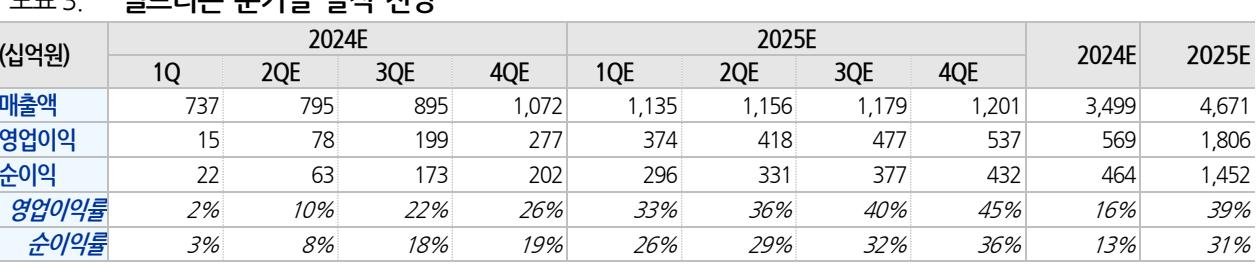

In [28]:
# 검색된 이미지 중 마지막 이미지 시각화
if result["context"]["images"]:
    plt_img_base64(result["context"]["images"][-1])
else:
    print("⚠️ 검색 결과에 이미지가 없습니다.")


In [29]:
# RAG 파이프라인 실행
result = rag_chain_with_sources.invoke("삼성전기 주가 전망을 보여주는 이미지?")

# 결과 출력
print(result['response'])

# 검색된 문서
print(result['context'])

삼성전기의 주가 전망 이미지는 다음과 같습니다.

- 투자 의견은 BUY(유지)이며,
- 목표 주가는 200,000원(상향)입니다.
- 현재 주가는 156,600원(2024년 5월 30일 기준)입니다.
- 시가 총액은 11,697십억원 수준입니다.

과거 2년간 투자 의견 및 목표 주가 변동 내역과 주가 및 목표 주가 추이 그래프를 통해, 목표 주가가 최근 상향 조정된 점을 확인할 수 있습니다.  
(출처: [2] doc·page 1에 근거)
{'texts': [Document(metadata={'doc_id': '7504ece4-bcee-4e48-a1c5-0a9a06377f30', 'source': 'text', 'page_number': 2, 'doc_name': '20240531_company_652771000.pdf'}, page_content='삼 성 전 기\n\n삼 성 전 기 (009150.9) 재 무 제표\n\n대 차 대조표\n\n( 단 위 : 십 억원) 20224 20234 20240 202 202 자 산 총계 10.997 11,658 11,969 13,007 14,240 유 동 자산 4888 5,208 5,050 6208 7,529 현 금 성 자산 1737 17728 2.000 2933 4007 매 출 채권 1,062 1,241 1,088 1,172 1,263 재 고 자산 1,902 2,120 1,841 1,982 2,136 비 유 동 자산 6.109 6449 6919 6798 6710 투 자 자 산 724 695 705 734 763 유 형 자산 5235 5603 6056 5894 5,767 기 티 150 151 158 171 180 부 채 총계 3304 3628 4,026 4,456 4,940 유 동 부차 2525 2,900 3196 3529 3914 매 입 채무 1.239 1,325 1,119 1,205 1,299 유 동 성 이 자 부채 1,109 1,330 1,829 2,073 2363 기 티 178 245 248 250 253 비 유 


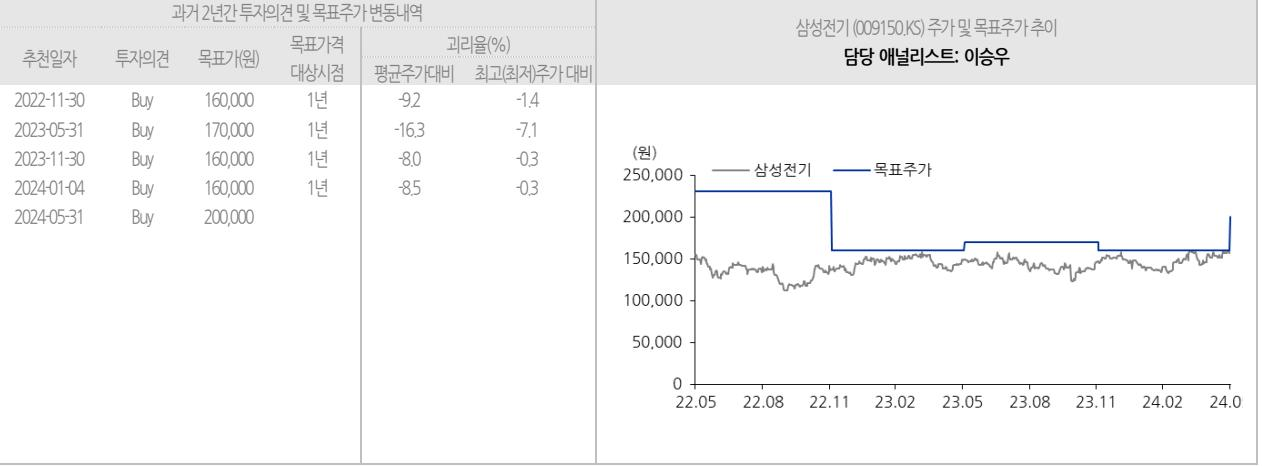

In [30]:
# 검색된 이미지 중 두 번째 시각화 (인덱스 가드)
if len(result["context"]["images"]) > 1:
    plt_img_base64(result["context"]["images"][1])
elif result["context"]["images"]:
    plt_img_base64(result["context"]["images"][0])
else:
    print("⚠️ 검색 결과에 이미지가 없습니다.")


---
## **[실습 프로젝트]**

이 실습에서는 옵션 2와 옵션 3의 멀티모달 RAG 시스템을 비교하고, 실제 증권사 분석보고서 질의응답 시스템을 구축합니다.

### **과제: 옵션 2와 옵션 3 비교 분석**

다음 질문들로 두 옵션을 테스트하고 결과를 비교하세요:

1. "삼성전기의 2024년 실적 전망을 그래프와 함께 설명해주세요."
2. "셀트리온의 주요 제품 매출 비중을 테이블로 보여주세요."
3. "LG전자의 분기별 영업이익률 추이는 어떻게 되나요?"

**비교 항목:**
- 답변 품질 (정확도, 상세함)
- 이미지/테이블 활용도
- 응답 시간
- API 비용 (토큰 사용량)

```python
# 옵션 2 결과
option2_result = ...

# 옵션 3 결과
option3_result = ...

# 비교 분석 코드 작성
```

In [ ]:
# 여기에 코드를 작성하세요.

### **제출 가이드**

1. 각 과제별로 실행 결과 캡처
2. 옵션 2와 옵션 3의 장단점 분석 (200자 이내)
3. 실전 시나리오 구현 코드와 테스트 결과

**평가 기준:**
- 코드 완성도 (40%)
- 실험 결과 분석 (30%)
- 창의성 및 실용성 (30%)
